In [2]:
import numpy as np
import matplotlib.pyplot as plt
import Tdoa
import Aoa
import Hybrid
import Comm as com
import Multipath as mp
import importlib
import util

In [3]:
plt.rcParams.update({
    "font.size": 13,
    "font.family": "serif",
    "mathtext.fontset": "cm",  # This gives the LaTeX look to math text
    "axes.edgecolor": "black", # Black bounding box
    "axes.linewidth": 0.8
})

In [4]:
num_rx = 4

In [5]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

tdoa_errors = []
aoa_errors = []
hybrid_errors = []
hybrid_ransac_errors = []
hybrid_ransac_fo_errors = []

for i in range(8):
    for j in range(5):
        filename = f"Small8/taps_estimates_{i}_{j}.csv"
        TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

        for iter in range(1):

            taus_hat = data[f'{iter}']['delays']
            angles_hat = data[f'{iter}']['angles']

            first_toas = np.zeros(num_rx)
            for RX_idx in range(num_rx):
                first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                first_toas[RX_idx] = first_toa

            first_aoas = np.zeros(num_rx)
            for RX_idx in range(num_rx):
                first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

            # TDOA localization using first path
            TdoaLocalizer = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
            position_estimate_tdoa = TdoaLocalizer.localize()
            tdoa_errors.append(np.linalg.norm(position_estimate_tdoa - TX_position[:2]))

            # AOA localization using first path
            AoaLocalizer = Aoa.AoaLocalization(first_aoas, [rx[:2] for rx in RX_positions])
            position_estimate_aoa = AoaLocalizer.localize_least_squares()
            aoa_errors.append(np.linalg.norm(position_estimate_aoa - TX_position[:2]))

            # Hybrid localization
            HybridLocalizer = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
            position_estimate_hybrid = HybridLocalizer.localize()
            hybrid_errors.append(np.linalg.norm(position_estimate_hybrid - TX_position[:2]))

            # Hybrid localization with RANSAC
            position_estimate_hybrid_ransac = HybridLocalizer.localize_ransac(iter=100, threshold=0.5)
            hybrid_ransac_errors.append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))

            # Hybrid localization with RANSAC + first-order reflections
            try:
                position_estimate_hybrid_ransac_fo = HybridLocalizer.localize_iterative2(iter=100, threshold=0.5)
                hybrid_ransac_fo_errors.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))
            except Exception as e:
                print(f"Error occurred while localizing with RANSAC + FO: {e}")
                print(taus_hat)

KeyboardInterrupt: 

In [6]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

tdoa_errors_4 = []
tdoa_errors_4_bis = []
tdoa_errors_6 = []
tdoa_errors_6_bis = []
tdoa_errors_8 = []
tdoa_errors_8_bis = []

len_tdoa_4 = []
len_tdoa_6 = []
len_tdoa_8 = []

for i in range(8):
    for j in range(5):
        for num_rx in [4, 6, 8]:
            filename = f"Small{num_rx}/taps_estimates_{i}_{j}.csv"
            TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

            for iter in range(10):
                
                taus_hat = data[f'{iter}']['delays']
                angles_hat = data[f'{iter}']['angles']

                first_toas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                    first_toas[RX_idx] = first_toa

                first_aoas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

                # TDOA localization using first path
                TdoaLocalizer = Tdoa.TdoaLocalization([rx[:2] for rx in RX_positions], first_toas)
                position_estimate_tdoa = TdoaLocalizer.localize()
                position_estimate_tdoa_bis = TdoaLocalizer.localize_least_squares()
                if num_rx == 4:
                    len_tdoa_4.append(len(TdoaLocalizer.tdoas))
                    tdoa_errors_4.append(np.linalg.norm(position_estimate_tdoa - TX_position[:2]))
                    tdoa_errors_4_bis.append(np.linalg.norm(position_estimate_tdoa_bis - TX_position[:2]))
                elif num_rx == 6:
                    len_tdoa_6.append(len(TdoaLocalizer.tdoas))
                    tdoa_errors_6.append(np.linalg.norm(position_estimate_tdoa - TX_position[:2]))
                    tdoa_errors_6_bis.append(np.linalg.norm(position_estimate_tdoa_bis - TX_position[:2]))
                elif num_rx == 8:
                    len_tdoa_8.append(len(TdoaLocalizer.tdoas))
                    tdoa_errors_8.append(np.linalg.norm(position_estimate_tdoa - TX_position[:2]))
                    tdoa_errors_8_bis.append(np.linalg.norm(position_estimate_tdoa_bis - TX_position[:2]))


In [7]:

# count the number of occurrences of each number of TDOAs for each number of RXs
from collections import Counter
counter_4 = Counter(len_tdoa_4)
counter_6 = Counter(len_tdoa_6)
counter_8 = Counter(len_tdoa_8)

print("TDOA counts for 4 RXs:", counter_4)
print("TDOA counts for 6 RXs:", counter_6)
print("TDOA counts for 8 RXs:", counter_8)

TDOA counts for 4 RXs: Counter({3: 198, 2: 192, 1: 10})
TDOA counts for 6 RXs: Counter({4: 251, 5: 100, 3: 39, 2: 10})
TDOA counts for 8 RXs: Counter({6: 213, 7: 100, 5: 67, 4: 20})


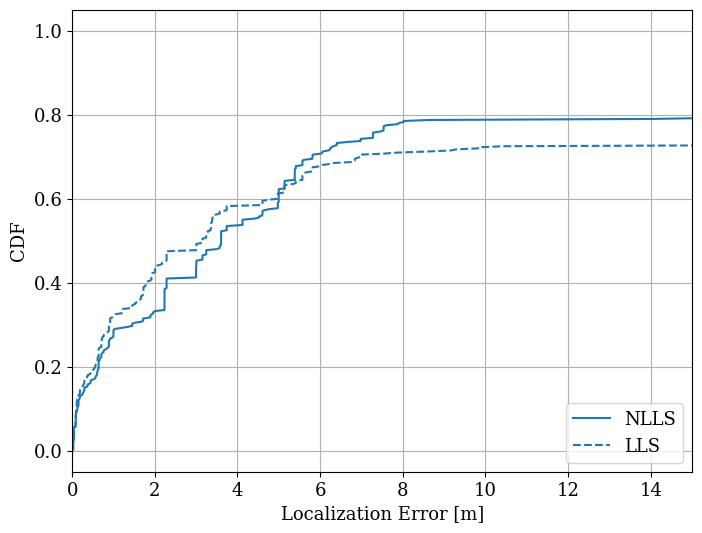

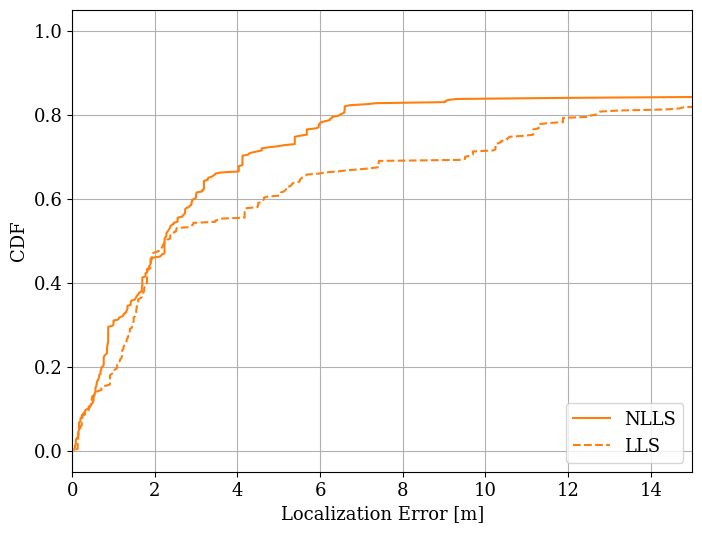

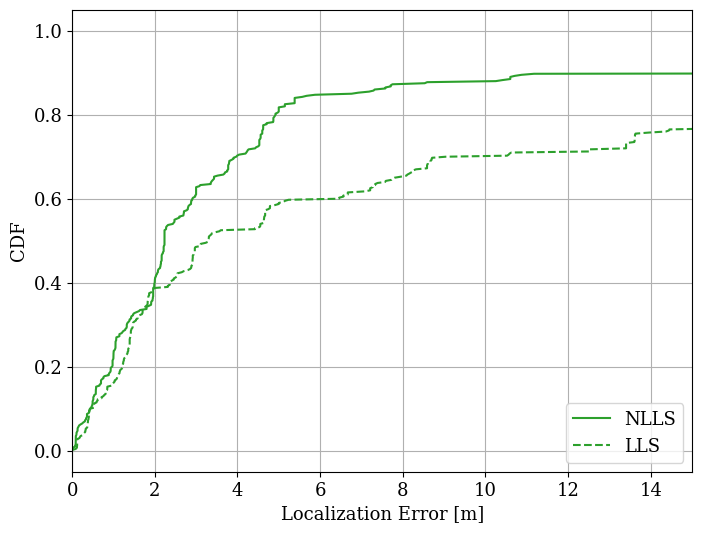

In [8]:
tdoa_errors_4_plot = np.sort(np.array(tdoa_errors_4))
tdoa_errors_4_bis_plot = np.sort(np.array(tdoa_errors_4_bis))
tdoa_errors_6_plot = np.sort(np.array(tdoa_errors_6))
tdoa_errors_6_bis_plot = np.sort(np.array(tdoa_errors_6_bis))
tdoa_errors_8_plot = np.sort(np.array(tdoa_errors_8))
tdoa_errors_8_bis_plot = np.sort(np.array(tdoa_errors_8_bis))


cumulative = np.arange(1, len(tdoa_errors_4_plot) + 1) / len(tdoa_errors_4_plot)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(tdoa_errors_4_plot, cumulative, label='NLLS', color='tab:blue')
ax.plot(tdoa_errors_4_bis_plot, cumulative, label='LLS', linestyle='--', color='tab:blue')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 15)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
plt.savefig('tdoa_cdf_small_4.pdf', bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(tdoa_errors_6_plot, cumulative, label='NLLS', color='tab:orange')
ax.plot(tdoa_errors_6_bis_plot, cumulative, label='LLS', linestyle='--', color='tab:orange')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 15)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
plt.savefig('tdoa_cdf_small_6.pdf', bbox_inches='tight')
plt.show()


fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(tdoa_errors_8_plot, cumulative, label='NLLS', color='tab:green')
ax.plot(tdoa_errors_8_bis_plot, cumulative, label='LLS', linestyle='--', color='tab:green')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 15)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
plt.savefig('tdoa_cdf_small_8.pdf', bbox_inches='tight')
plt.show()

In [9]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

aoa_errors_4 = []
aoa_errors_6 = [] = []
aoa_errors_8 = [] = []


for i in range(8):
    for j in range(5):
        for num_rx in [4, 6, 8]:
            filename = f"Large{num_rx}/taps_estimates_{i}_{j}.csv"
            TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

            for iter in range(10):
                
                taus_hat = data[f'{iter}']['delays']
                angles_hat = data[f'{iter}']['angles']

                first_toas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                    first_toas[RX_idx] = first_toa

                first_aoas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

                # AOA localization using first path
                AoALocalizer = Aoa.AoaLocalization(first_aoas, [rx[:2] for rx in RX_positions])
                position_estimate_aoa = AoALocalizer.localize_least_squares()
                if num_rx == 4:
                    aoa_errors_4.append(np.linalg.norm(position_estimate_aoa - TX_position[:2]))
                elif num_rx == 6:
                    aoa_errors_6.append(np.linalg.norm(position_estimate_aoa - TX_position[:2]))
                elif num_rx == 8:
                    aoa_errors_8.append(np.linalg.norm(position_estimate_aoa - TX_position[:2]))


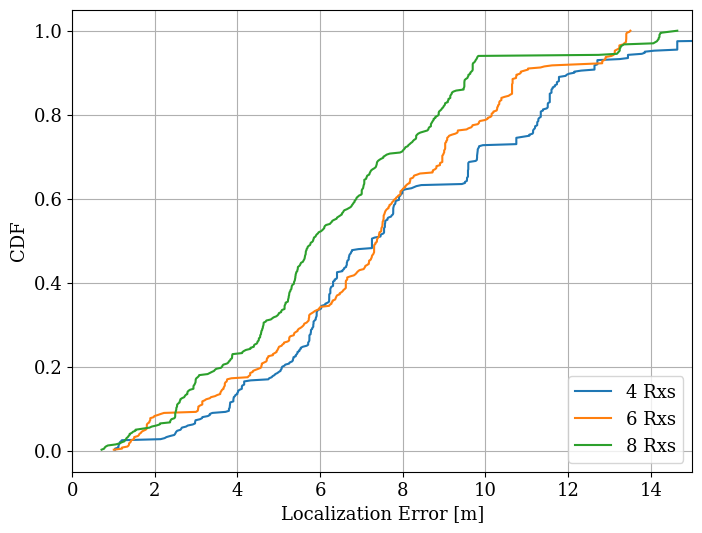

In [10]:
aoa_errors_4_plot = np.sort(np.array(aoa_errors_4))
aoa_errors_6_plot = np.sort(np.array(aoa_errors_6))
aoa_errors_8_plot = np.sort(np.array(aoa_errors_8))


cumulative = np.arange(1, len(aoa_errors_4_plot) + 1) / len(aoa_errors_4_plot)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(aoa_errors_4_plot, cumulative, label='4 Rxs', color='tab:blue')
ax.plot(aoa_errors_6_plot, cumulative, label='6 Rxs', linestyle='-', color='tab:orange')
ax.plot(aoa_errors_8_plot, cumulative, label='8 Rxs', linestyle='-', color='tab:green')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 15)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
plt.savefig('aoa_cdf_large.pdf', bbox_inches='tight')
plt.show()

In [45]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

hybrid_errors_4 = []
hybrid_errors_6 = []
hybrid_errors_8 = []


for i in range(8):
    for j in range(5):
        for num_rx in [4, 6, 8]:
            filename = f"Small{num_rx}/taps_estimates_{i}_{j}.csv"
            TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

            for iter in range(10):
                
                taus_hat = data[f'{iter}']['delays']
                angles_hat = data[f'{iter}']['angles']

                first_toas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                    first_toas[RX_idx] = first_toa

                first_aoas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

                # Hybrid localization using first path
                HybridLocalizer = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
                position_estimate_hybrid = HybridLocalizer.localize()
                if num_rx == 4:
                    hybrid_errors_4.append(np.linalg.norm(position_estimate_hybrid - TX_position[:2]))
                elif num_rx == 6:
                    hybrid_errors_6.append(np.linalg.norm(position_estimate_hybrid - TX_position[:2]))
                elif num_rx == 8:
                    hybrid_errors_8.append(np.linalg.norm(position_estimate_hybrid - TX_position[:2]))


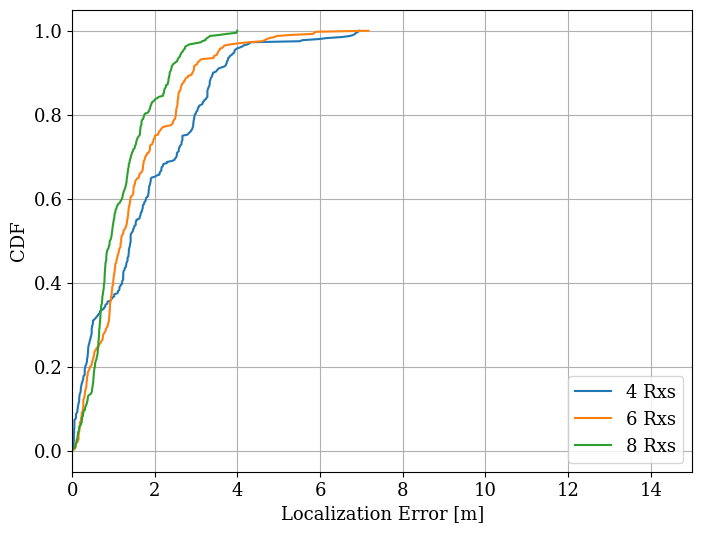

In [46]:
hybrid_errors_4_plot = np.sort(np.array(hybrid_errors_4))
hybrid_errors_6_plot = np.sort(np.array(hybrid_errors_6))
hybrid_errors_8_plot = np.sort(np.array(hybrid_errors_8))


cumulative = np.arange(1, len(hybrid_errors_4_plot) + 1) / len(hybrid_errors_4_plot)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(hybrid_errors_4_plot, cumulative, label='4 Rxs', color='tab:blue')
ax.plot(hybrid_errors_6_plot, cumulative, label='6 Rxs', linestyle='-', color='tab:orange')
ax.plot(hybrid_errors_8_plot, cumulative, label='8 Rxs', linestyle='-', color='tab:green')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 15)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
# plt.savefig('hybrid_cdf_large.pdf', bbox_inches='tight')
plt.show()

In [73]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

hybrid_ransac_errors_4 = []
hybrid_ransac_errors_6 = []
hybrid_ransac_errors_8 = []


for i in range(8):
    for j in range(5):
        for num_rx in [4, 6, 8]:
            filename = f"Large{num_rx}/taps_estimates_{i}_{j}.csv"
            TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

            for iter in range(10):
                
                taus_hat = data[f'{iter}']['delays']
                angles_hat = data[f'{iter}']['angles']

                first_toas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                    first_toas[RX_idx] = first_toa

                first_aoas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

                # Hybrid localization using first path
                HybridLocalizer = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
                position_estimate_hybrid_ransac = HybridLocalizer.localize_ransac(threshold=0.25)
                if num_rx == 4:
                    hybrid_ransac_errors_4.append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))
                elif num_rx == 6:
                    hybrid_ransac_errors_6.append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))
                elif num_rx == 8:
                    hybrid_ransac_errors_8.append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))


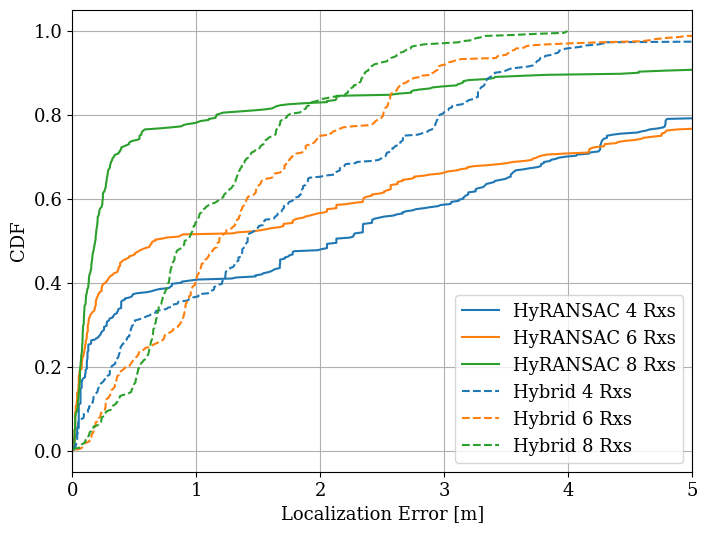

In [74]:
hybrid_ransac_errors_4_plot = np.sort(np.array(hybrid_ransac_errors_4))
hybrid_ransac_errors_6_plot = np.sort(np.array(hybrid_ransac_errors_6))
hybrid_ransac_errors_8_plot = np.sort(np.array(hybrid_ransac_errors_8))


cumulative = np.arange(1, len(hybrid_ransac_errors_4_plot) + 1) / len(hybrid_ransac_errors_4_plot)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(hybrid_ransac_errors_4_plot, cumulative, label='HyRANSAC 4 Rxs', color='tab:blue')
ax.plot(hybrid_ransac_errors_6_plot, cumulative, label='HyRANSAC 6 Rxs', linestyle='-', color='tab:orange')
ax.plot(hybrid_ransac_errors_8_plot, cumulative, label='HyRANSAC 8 Rxs', linestyle='-', color='tab:green')
ax.plot(hybrid_errors_4_plot, cumulative, label='Hybrid 4 Rxs', linestyle='--', color='tab:blue')
ax.plot(hybrid_errors_6_plot, cumulative, label='Hybrid 6 Rxs', linestyle='--', color='tab:orange')
ax.plot(hybrid_errors_8_plot, cumulative, label='Hybrid 8 Rxs', linestyle='--', color='tab:green')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 5)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
# plt.savefig('hybrid_ransac_cdf_small.pdf', bbox_inches='tight')
plt.show()

In [56]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

hybrid_ransac_errors_4 = [[], [], [], [], []]
hybrid_ransac_errors_6 = [[], [], [], [], []]
hybrid_ransac_errors_8= [[], [], [], [], []]

for i in range(8):
    for j in range(5):
        for num_rx in [4, 6, 8]:
            filename = f"Large{num_rx}/taps_estimates_{i}_{j}.csv"
            TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

            for iter in range(10):
                
                taus_hat = data[f'{iter}']['delays']
                angles_hat = data[f'{iter}']['angles']

                first_toas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                    first_toas[RX_idx] = first_toa

                first_aoas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

                # Hybrid localization using first path
                HybridLocalizer = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
                for t, threshold in enumerate([0.1, 0.25, 0.5, 1.0, 2.0]):
                    position_estimate_hybrid_ransac = HybridLocalizer.localize_ransac(threshold=threshold)
                    if num_rx == 4:
                        hybrid_ransac_errors_4[t].append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))
                    elif num_rx == 6:
                        hybrid_ransac_errors_6[t].append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))
                    elif num_rx == 8:
                        hybrid_ransac_errors_8[t].append(np.linalg.norm(position_estimate_hybrid_ransac - TX_position[:2]))


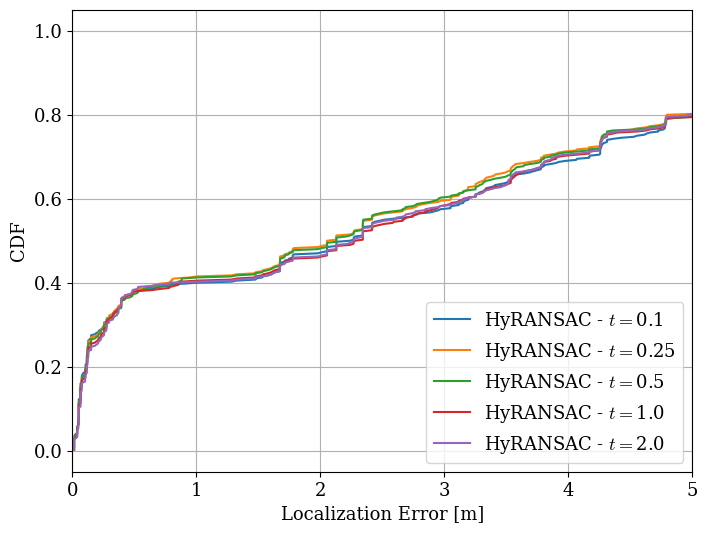

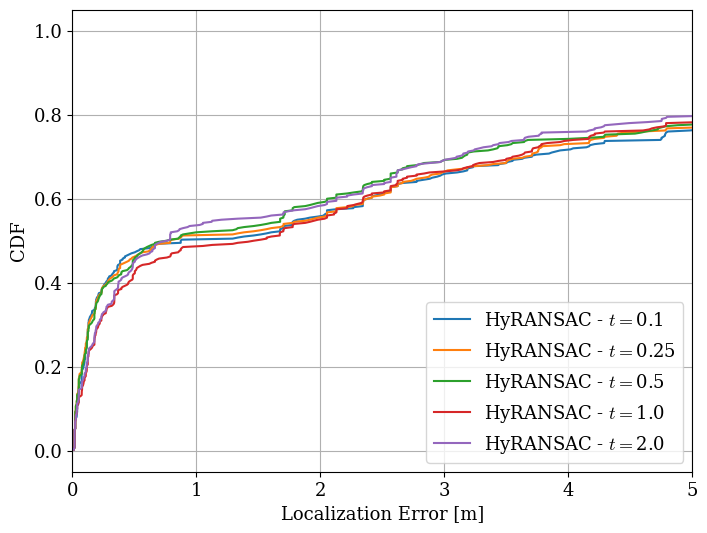

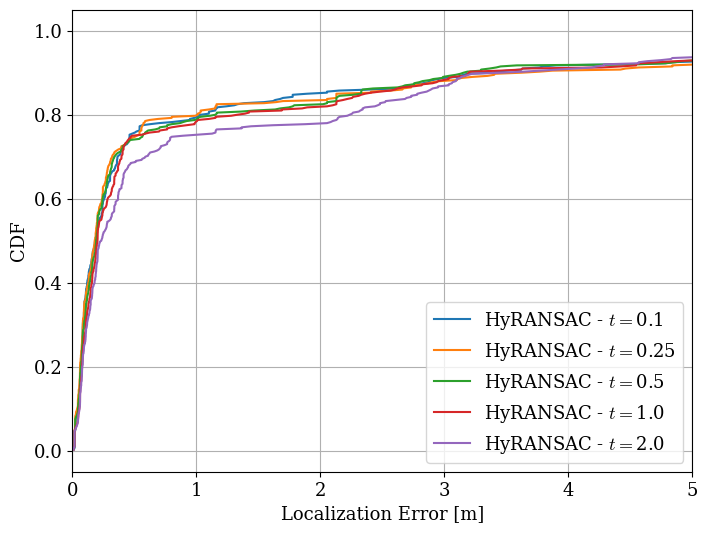

In [57]:
hybrid_ransac_errors_4_plot = [np.sort(np.array(hybrid_ransac_errors_4[t])) for t in range(5)]
hybrid_ransac_errors_6_plot = [np.sort(np.array(hybrid_ransac_errors_6[t])) for t in range(5)]
hybrid_ransac_errors_8_plot = [np.sort(np.array(hybrid_ransac_errors_8[t])) for t in range(5)]


cumulative = np.arange(1, len(hybrid_ransac_errors_4_plot[0]) + 1) / len(hybrid_ransac_errors_4_plot[0])

fig, ax = plt.subplots(figsize=(8, 6))

for t, threshold in enumerate([0.1, 0.25, 0.5, 1.0, 2.0]):
    ax.plot(hybrid_ransac_errors_4_plot[t], cumulative, label=r'HyRANSAC - $t=$'+f'{threshold}')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 5)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
plt.savefig('hybrid_ransac_cdf_large_threshold_rx4.pdf', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))

for t, threshold in enumerate([0.1, 0.25, 0.5, 1.0, 2.0]):
    ax.plot(hybrid_ransac_errors_6_plot[t], cumulative, label=r'HyRANSAC - $t=$'+f'{threshold}')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 5)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
plt.savefig('hybrid_ransac_cdf_large_threshold_rx6.pdf', bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))

for t, threshold in enumerate([0.1, 0.25, 0.5, 1.0, 2.0]):
    ax.plot(hybrid_ransac_errors_8_plot[t], cumulative, label=r'HyRANSAC - $t=$'+f'{threshold}')  

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 5)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
plt.savefig('hybrid_ransac_cdf_large_threshold_rx8.pdf', bbox_inches='tight')
plt.show()

In [78]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

hybrid_ransac_errors_fo_4 = []
hybrid_ransac_errors_fo_6 = []
hybrid_ransac_errors_fo_8 = []


for i in range(8):
    for j in range(5):
        for num_rx in [4, 6, 8]:
            filename = f"Large{num_rx}/taps_estimates_{i}_{j}.csv"
            TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

            for iter in range(10):
                
                taus_hat = data[f'{iter}']['delays']
                angles_hat = data[f'{iter}']['angles']

                first_toas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                    first_toas[RX_idx] = first_toa

                first_aoas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

                # Hybrid localization using first path
                HybridLocalizer = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
                position_estimate_hybrid_ransac_fo = HybridLocalizer.localize_ransac_fo(iter=1,threshold=0.25)
                if num_rx == 4:
                    hybrid_ransac_errors_fo_4.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))
                elif num_rx == 6:
                    hybrid_ransac_errors_fo_6.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))
                elif num_rx == 8:
                    hybrid_ransac_errors_fo_8.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))


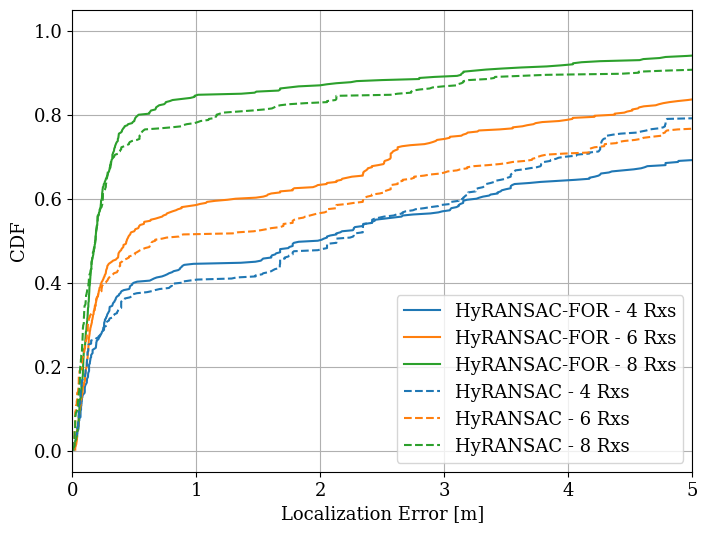

In [84]:
hybrid_ransac_fo_errors_4_plot = np.sort(np.array(hybrid_ransac_errors_fo_4))
hybrid_ransac_fo_errors_6_plot = np.sort(np.array(hybrid_ransac_errors_fo_6))
hybrid_ransac_fo_errors_8_plot = np.sort(np.array(hybrid_ransac_errors_fo_8))


cumulative = np.arange(1, len(hybrid_ransac_fo_errors_4_plot) + 1) / len(hybrid_ransac_fo_errors_4_plot)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(hybrid_ransac_fo_errors_4_plot, cumulative, label='HyRANSAC-FOR - 4 Rxs', color='tab:blue')
ax.plot(hybrid_ransac_fo_errors_6_plot, cumulative, label='HyRANSAC-FOR - 6 Rxs', linestyle='-', color='tab:orange')
ax.plot(hybrid_ransac_fo_errors_8_plot, cumulative, label='HyRANSAC-FOR - 8 Rxs', linestyle='-', color='tab:green')
ax.plot(hybrid_ransac_errors_4_plot, cumulative, label='HyRANSAC - 4 Rxs', linestyle='--', color='tab:blue')
ax.plot(hybrid_ransac_errors_6_plot, cumulative, label='HyRANSAC - 6 Rxs', linestyle='--', color='tab:orange')
ax.plot(hybrid_ransac_errors_8_plot, cumulative, label='HyRANSAC - 8 Rxs', linestyle='--', color='tab:green')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 5)
ax.set_ylim(-0.05, 1.05)
ax.legend(loc='lower right')
ax.grid()
plt.savefig('hybrid_ransac_for_cdf_large.pdf', bbox_inches='tight')
plt.show()

In [80]:
importlib.reload(Aoa)
importlib.reload(Tdoa)
importlib.reload(Hybrid)

# Read the taps computed by MUSIC from the CSV file
# And perform localization using TDOA, AOA, and Hybrid methods

hybrid_ransac_errors_fo_4_bis = []
hybrid_ransac_errors_fo_6_bis = []
hybrid_ransac_errors_fo_8_bis = []


for i in range(8):
    for j in range(5):
        for num_rx in [4, 6, 8]:
            filename = f"Large{num_rx}/taps_estimates_{i}_{j}.csv"
            TX_position, RX_positions, RX_orientations, data = util.read_taps_from_csv(filename)

            for iter in range(10):
                
                taus_hat = data[f'{iter}']['delays']
                angles_hat = data[f'{iter}']['angles']

                first_toas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_toa = taus_hat[RX_idx][0] if len(taus_hat[RX_idx]) > 0 else -1
                    first_toas[RX_idx] = first_toa

                first_aoas = np.zeros(num_rx)
                for RX_idx in range(num_rx):
                    first_aoa = angles_hat[RX_idx][0] if len(angles_hat[RX_idx]) > 0 else 4
                    first_aoas[RX_idx] = util.global_angle(first_aoa, RX_orientations[RX_idx])

                # Hybrid localization using first path
                HybridLocalizer = Hybrid.HybridLocalization([rx[:2] for rx in RX_positions], RX_orientations, taus_hat, angles_hat)
                position_estimate_hybrid_ransac_fo = HybridLocalizer.localize_ransac_fo(iter=2,threshold=0.25)
                if num_rx == 4:
                    hybrid_ransac_errors_fo_4_bis.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))
                elif num_rx == 6:
                    hybrid_ransac_errors_fo_6_bis.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))
                elif num_rx == 8:
                    hybrid_ransac_errors_fo_8_bis.append(np.linalg.norm(position_estimate_hybrid_ransac_fo - TX_position[:2]))


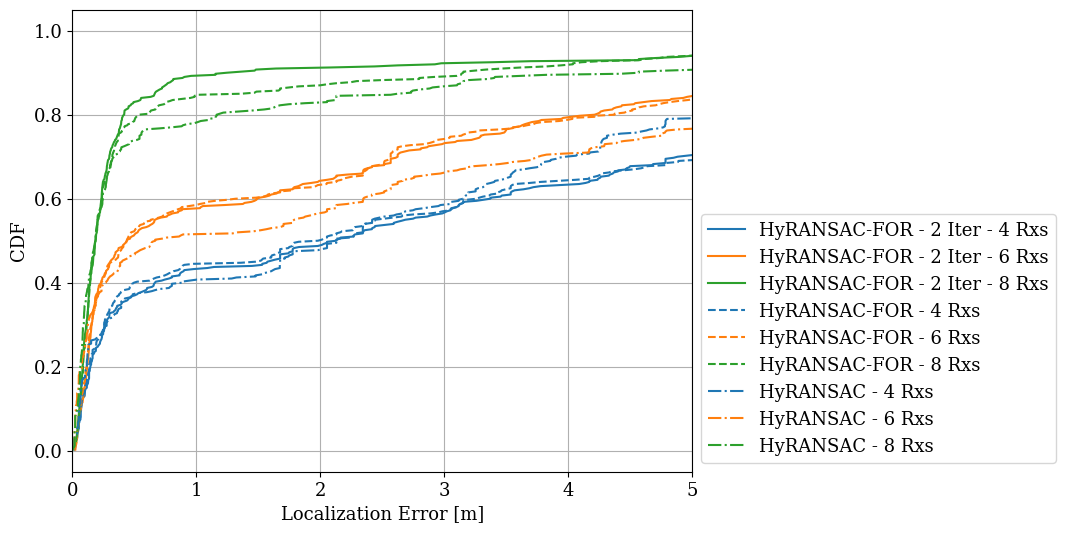

: 

In [ ]:
hybrid_ransac_fo_errors_4_bis_plot = np.sort(np.array(hybrid_ransac_errors_fo_4_bis))
hybrid_ransac_fo_errors_6_bis_plot = np.sort(np.array(hybrid_ransac_errors_fo_6_bis))
hybrid_ransac_fo_errors_8_bis_plot = np.sort(np.array(hybrid_ransac_errors_fo_8_bis))


cumulative = np.arange(1, len(hybrid_ransac_fo_errors_4_bis_plot) + 1) / len(hybrid_ransac_fo_errors_4_bis_plot)

fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(hybrid_ransac_fo_errors_4_bis_plot, cumulative, label='HyRANSAC-FOR - 2 Iter - 4 Rxs', color='tab:blue')
ax.plot(hybrid_ransac_fo_errors_6_bis_plot, cumulative, label='HyRANSAC-FOR - 2 Iter - 6 Rxs', linestyle='-', color='tab:orange')
ax.plot(hybrid_ransac_fo_errors_8_bis_plot, cumulative, label='HyRANSAC-FOR - 2 Iter - 8 Rxs', linestyle='-', color='tab:green')
ax.plot(hybrid_ransac_fo_errors_4_plot, cumulative, label='HyRANSAC-FOR - 4 Rxs', linestyle='--', color='tab:blue')
ax.plot(hybrid_ransac_fo_errors_6_plot, cumulative, label='HyRANSAC-FOR - 6 Rxs', linestyle='--', color='tab:orange')
ax.plot(hybrid_ransac_fo_errors_8_plot, cumulative, label='HyRANSAC-FOR - 8 Rxs', linestyle='--', color='tab:green')
ax.plot(hybrid_ransac_errors_4_plot, cumulative, label='HyRANSAC - 4 Rxs', linestyle='-.', color='tab:blue')
ax.plot(hybrid_ransac_errors_6_plot, cumulative, label='HyRANSAC - 6 Rxs', linestyle='-.', color='tab:orange')
ax.plot(hybrid_ransac_errors_8_plot, cumulative, label='HyRANSAC - 8 Rxs', linestyle='-.', color='tab:green')

ax.set_xlabel('Localization Error [m]')
ax.set_ylabel('CDF')
ax.set_xlim(0, 5)
ax.set_ylim(-0.05, 1.05)
ax.legend(bbox_to_anchor=(1.0, 0), loc='lower left')
ax.grid()
plt.savefig('hybrid_ransac_for_cdf_large2.pdf', bbox_inches='tight')
plt.show()